# Week 1 Day 4 — Linear Regression from Scratch

## What I built:
- Implemented linear regression using least squares formula in NumPy
- Plotted regression line on scatter plot
- Calculated R² manually
- Verified all results match sklearn exactly

## Key formulas:
- slope     = Σ(x - x_mean)(y - y_mean) / Σ(x - x_mean)²
- intercept = y_mean - slope * x_mean
- R²        = 1 - (SS_res / SS_tot)

## Result:
- Slope: 0.04 — each sq ft adds 4000 rupees to price
- Intercept: 14.87 — base price
- R²: 0.9944 — model explains 99.44% of variance

# Dataset and Scatter PLot

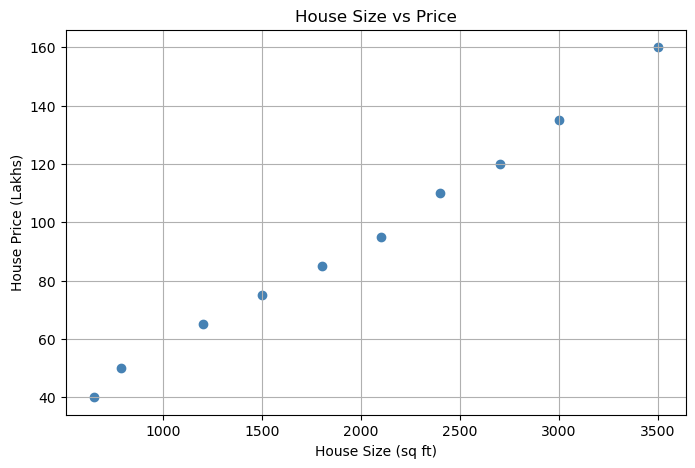

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# house size (sq ft) vs price (lakhs)
np.random.seed(42)
house_size  = np.array([650, 785, 1200, 1500, 1800, 
                         2100, 2400, 2700, 3000, 3500])
house_price = np.array([40, 50, 65, 75, 85, 
                         95, 110, 120, 135, 160])
plt.figure(figsize=(8, 5))
plt.scatter(house_size, house_price, color='steelblue')
plt.title('House Size vs Price')
plt.xlabel('House Size (sq ft)')
plt.ylabel('House Price (Lakhs)')
plt.grid(True)
plt.show()

# Linear Regression From Scratch

In [8]:
x_mean = np.mean(house_size)
y_mean = np.mean(house_price)

slope     = np.sum((house_size  - x_mean) *(house_price - y_mean)) / np.sum((house_size  - x_mean) ** 2)

intercept = y_mean - (slope * x_mean)

print(f"  Slope         : {slope:.4f}")
print(f"  Intercept     : {intercept:.4f}")

  Slope         : 0.0400
  Intercept     : 14.8727


# Predictions and PLot Regression Line

In [ ]:
predicted_price = slope * house_size + intercept

plt.figure(figsize=(8, 5))
plt.scatter(house_size, house_price, color='steelblue', label='Actual Data')
plt.plot(house_size, predicted_price, color='red', label='Regression Line')
plt.title('Linear Regression — House Size vs Price')
plt.xlabel('House Size (sq ft)')
plt.ylabel('House Price (Lakhs)')
plt.legend()
plt.grid(True)
plt.savefig('linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()

# R2 Score

In [ ]:
house_price_mean = np.mean(house_price)
SS_res = np.sum((house_price-predicted_price)**2)
SS_tot = np.sum((house_price-house_price_mean)**2)
R2     = 1 - (SS_res / SS_tot)
print(f"  R² (manual)   : {R2:.4f}")

# Verify With SKLearn

In [ ]:
from sklearn.linear_model import LinearRegression

# sklearn needs 2D array for X
X = house_size.reshape(-1, 1)  # shape (10,) → (10, 1)
y = house_price

model = LinearRegression()
model.fit(X, y)

print(f"Sklearn Slope     : {model.coef_[0]:.4f}")
print(f"Sklearn Intercept : {model.intercept_:.4f}")
print(f"Sklearn R²        : {model.score(X, y):.4f}")

print(f"\nYour Slope        : {slope:.4f}")
print(f"Your Intercept    : {intercept:.4f}")
print(f"Your R²           : {R2:.4f}")